# 01 — Data preparation

**Goal.** Understand what is actually in these files before any modelling touches them.

| | |
|---|---|
| **Reads** | `data/raw/lalonde/*.txt` |
| **Writes** | `outputs/data/01_sample_cps.csv`, `01_sample_psid.csv`, `01_benchmark.json` |

**Questions this notebook answers**

1. What columns are there, and what does each one mean?
2. Are the data types right?
3. How are the numeric variables distributed?
4. Are there rows that need handling before modelling?
5. Are the categorical variables coded correctly?

Then, once the data is understood: what is the experimental benchmark, and what do the two
observational samples look like?

Every claim below is backed by output in the cell beside it. Nothing is asserted on trust.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import warnings

# this environment ships slightly old numexpr/bottleneck; the warnings are noise
warnings.filterwarnings("ignore", message=".*numexpr.*")
warnings.filterwarnings("ignore", message=".*bottleneck.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src import psm, data, figures

pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

%matplotlib inline

## 1. What is in the files

Four files, ten columns each, no header row, whitespace separated.

**Who these people are.** The National Supported Work Demonstration ran from 1975 to 1979 and
targeted the hardest-to-employ: long-term welfare recipients, ex-offenders, recovering addicts,
and teenagers who had left school and never held steady work. Its premise was that the binding
constraint was not skills but the absence of any bridge into the labor market — no work history,
no references, and no employer willing to tolerate a slow start. So it offered 9 to 18 months of
paid work with close supervision and demands that ramped up gradually, across ten cities.

More applicants than places meant admission was decided by lottery, and that single
administrative choice is the only reason a ground truth exists here. Two of these files are the
arms of that lottery. The other two are ordinary survey respondents with no connection to the
program. See [docs/background.md](../docs/background.md) for the full story.

In [2]:
raw = data.load_lalonde()

for name, df in raw.items():
    print(f"{name:12s} {len(df):>6,} rows x {df.shape[1]} cols")

print(f"\nall four share identical columns: {all(list(df.columns) == data.COLUMNS for df in raw.values())}")
print(f"columns: {data.COLUMNS}")
print()
raw["nsw_treated"].head(3)

nsw_treated     185 rows x 10 cols
nsw_control     260 rows x 10 cols
cps          15,992 rows x 10 cols
psid          2,490 rows x 10 cols

all four share identical columns: True
columns: ['treat', 'age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75', 're78']



,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,1,37.00,11.00,1,0,1,1,0.00,0.00,"9,930.05"
1,1,22.00,9.00,0,1,0,1,0.00,0.00,"3,595.89"
2,1,30.00,12.00,1,0,0,0,0.00,0.00,"24,909.45"


## 2. Column meanings and data types

| Column | Meaning | Kind | Timing |
|---|---|---|---|
| `treat` | enrolled in the program | indicator | assignment |
| `age` | age in years | numeric | pre-treatment |
| `educ` | years of schooling completed | numeric | pre-treatment |
| `black` | is Black | indicator | pre-treatment |
| `hisp` | is Hispanic | indicator | pre-treatment |
| `married` | is married | indicator | pre-treatment |
| `nodegree` | no high school diploma | indicator | pre-treatment |
| `re74` | real earnings, 1974 | numeric, dollars | **pre-treatment** |
| `re75` | real earnings, 1975 | numeric, dollars | **pre-treatment** |
| `re78` | real earnings, 1978 | numeric, dollars | **outcome** |

`re78` is the outcome and must never enter a balance check or a propensity model. `re74` and
`re75` are covariates. The randomized arms let us verify that claim rather than assume it, which
we do in section 6.

**Why the indicators become `int8` and not `category`.** They take part in arithmetic
everywhere: `df.treat.mean()` is the treated share, `y[t == 1]` subsets an arm, and
scikit-learn's `fit(X, y)` wants a numeric label. A categorical dtype breaks all three. The rule:
a binary indicator used in modelling is `int8` or `bool`; `category` is for unordered variables
with three or more levels that need encoding first. Every categorical here is already binary, so
nothing in this project needs `category`.

In [3]:
# what the raw text files give us, before any conversion
rawest = pd.read_csv(data.RAW_DIR / "nswre74_treated.txt", sep=r"\s+",
                     header=None, names=data.COLUMNS)
print("as parsed from disk:")
print(rawest.dtypes.value_counts().to_string())

print(f"\nafter load_raw narrows the {len(data.INDICATORS)} indicators:")
print(raw["nsw_treated"].dtypes.to_string())

print(f"\narithmetic still works on the narrowed columns:")
print(f"  treated share of the CPS sample = {pd.concat([raw['nsw_treated'], raw['cps']]).treat.mean():.4f}")

as parsed from disk:
float64    10

after load_raw narrows the 5 indicators:
treat          int8
age         float64
educ        float64
black          int8
hisp           int8
married        int8
nodegree       int8
re74        float64
re75        float64
re78        float64

arithmetic still works on the narrowed columns:
  treated share of the CPS sample = 0.0114


## 3. Data quality: missing, impossible, duplicated

Three checks. The first two come back clean; the third needs a judgement call.

In [4]:
all_rows = pd.concat([df.assign(src=k) for k, df in raw.items()], ignore_index=True)

print("MISSING VALUES")
print(f"  total NaN across all {len(all_rows):,} rows x {len(data.COLUMNS)} cols: "
      f"{int(all_rows[data.COLUMNS].isna().sum().sum())}")

print("\nIMPOSSIBLE VALUES")
print(f"  negative earnings          : {int((all_rows[['re74','re75','re78']] < 0).sum().sum())}")
print(f"  age outside 15-65          : {int(((all_rows.age < 15) | (all_rows.age > 65)).sum())}")
print(f"  educ outside 0-20          : {int(((all_rows.educ < 0) | (all_rows.educ > 20)).sum())}")
print(f"  observed age range         : {all_rows.age.min():.0f} to {all_rows.age.max():.0f}")
print(f"  observed educ range        : {all_rows.educ.min():.0f} to {all_rows.educ.max():.0f}")

print("\nPER-COLUMN REPORT (pooled across all four files)")
data.data_quality_report(all_rows[data.COLUMNS])

MISSING VALUES
  total NaN across all 18,927 rows x 10 cols: 0

IMPOSSIBLE VALUES
  negative earnings          : 0
  age outside 15-65          : 0
  educ outside 0-20          : 0
  observed age range         : 16 to 55
  observed educ range        : 0 to 18

PER-COLUMN REPORT (pooled across all four files)


,dtype,n_missing,n_distinct,min,max,pct_zero
treat,int8,0,2,0.00,1.00,99.02
age,float64,0,40,16.00,55.00,0.00
educ,float64,0,19,0.00,18.00,0.21
black,int8,0,2,0.00,1.00,88.53
hisp,int8,0,2,0.00,1.00,93.28
married,int8,0,2,0.00,1.00,28.07
nodegree,int8,0,2,0.00,1.00,69.15
re74,float64,0,8036,0.00,"137,148.68",12.97
re75,float64,0,8346,0.00,"156,653.23",12.08
re78,float64,0,8131,0.00,"121,173.58",13.71


### The one edge case: `educ == 0`

39 rows report zero years of schooling. That could be genuine (never attended) or a missing-value
code that was never documented. The neighbouring counts decide it: if zero were a missing code we
would expect a sharp spike, but 0 appears less often than 2 and about as often as 1 to 3. It
looks like a real if unusual value, and at 0.2% of the data the decision is low stakes either way.
Recorded here and left alone.

In [5]:
print("rows with educ == 0, by source file:")
print(all_rows.loc[all_rows.educ == 0, "src"].value_counts().to_string())

print("\ncounts at the low end of educ (is 0 a spike?):")
print(all_rows.educ.value_counts().sort_index().head(6).to_string())

rows with educ == 0, by source file:
src
cps     36
psid     3

counts at the low end of educ (is 0 a spike?):
educ
0.00     39
1.00     14
2.00     46
3.00     90
4.00    121
5.00    144


### Duplicated rows: 10.7% of CPS, and they must be kept

Whole-row duplicates are common here, especially in CPS. The instinct is to drop them. That would
be wrong, and the next cell shows why.

**One row is one person.** The three earnings years are stored as three *columns*, so this is
wide format, not panel data in long format. Identical records are therefore different people
colliding on ten coarse variables, not one person recorded repeatedly.

What makes the collisions likely is the topcode discovered in section 4: once earnings above a
ceiling are all rewritten to the same number, the variable that would otherwise separate two
people stops separating them. The evidence is in the cross-tab — duplicated rows are three times
as likely to carry a topcoded year as unique rows are.

Dropping them would delete real observations and shrink the control pool non-randomly, exactly
among the higher earners. **No de-duplication.**

*If this ever were true panel data with one person spread over several rows, the consequences
would be real: propensity estimation would treat each row as an independent observation,
over-weighting people with more rows, understating standard errors, and potentially matching a
person against another record of themselves. The fix then is to collapse to one row per person
at the time of treatment, or to cluster standard errors on person.*

In [6]:
print("fully duplicated rows, by file")
for name, df in raw.items():
    d = int(df.duplicated().sum())
    print(f"  {name:12s} {d:>6,}  ({d/len(df):>5.1%})")

cps = raw["cps"]
grp = cps[cps.duplicated(keep=False)].groupby(data.COLUMNS).size().sort_values(ascending=False)
print(f"\nthe most-repeated CPS record appears {grp.iloc[0]} times:")
print(pd.Series(dict(zip(data.COLUMNS, grp.index[0]))).to_string())

# is the topcode what causes the collisions?
TOPCODE = {"re74": 25862.32, "re75": 25243.55, "re78": 25564.67}
has_top = pd.concat([(cps[c].round(2) == v) for c, v in TOPCODE.items()], axis=1).any(axis=1)
is_dup = cps.duplicated(keep=False)
print("\nCPS rows cross-tabbed: duplicated vs carrying a topcoded year")
print(pd.crosstab(is_dup, has_top, rownames=["in a duplicate group"], colnames=["has topcoded year"]))
print(f"\n  duplicated rows with >=1 topcoded year : {has_top[is_dup].mean():>5.1%}")
print(f"  unique rows     with >=1 topcoded year : {has_top[~is_dup].mean():>5.1%}")

fully duplicated rows, by file
  nsw_treated       4  ( 2.2%)
  nsw_control      11  ( 4.2%)
  cps           1,716  (10.7%)
  psid            154  ( 6.2%)

the most-repeated CPS record appears 35 times:
treat           0.00
age            33.00
educ           12.00
black           0.00
hisp            0.00
married         1.00
nodegree        0.00
re74       25,862.32
re75       25,243.55
re78       25,564.67

CPS rows cross-tabbed: duplicated vs carrying a topcoded year
has topcoded year     False  True 
in a duplicate group              
False                 10306   3530
True                    480   1676

  duplicated rows with >=1 topcoded year : 77.7%
  unique rows     with >=1 topcoded year : 25.5%


## 4. Numeric distributions

Five numeric columns. Two things to look for: skew, which decides whether means are a sensible
summary, and any sign that the values were altered before publication.

In [7]:
num = ["age", "educ", "re74", "re75", "re78"]
desc = all_rows[num].describe(percentiles=[.25, .5, .75, .95, .99]).T
desc["skew"] = all_rows[num].skew()
desc["% zero"] = (all_rows[num] == 0).mean() * 100
desc.drop(columns="count").round(2)

,mean,std,min,25%,50%,75%,95%,99%,max,skew,% zero
age,33.25,10.97,16.00,24.00,31.00,42.00,53.00,55.00,55.00,0.36,0.00
educ,12.00,2.89,0.00,11.00,12.00,13.00,17.00,18.00,18.00,-0.41,0.21
re74,"14,448.66","10,425.78",0.00,"4,504.35","15,282.28","23,715.94","25,862.32","37,226.07","137,148.68",0.44,12.97
re75,"14,074.30","10,216.48",0.00,"4,363.02","14,680.64","23,177.52","25,243.55","37,596.77","156,653.23",0.55,12.08
re78,"15,504.62","10,914.24",0.00,"5,865.84","16,686.49","25,564.67","25,564.67","41,376.34","121,173.58",0.60,13.71


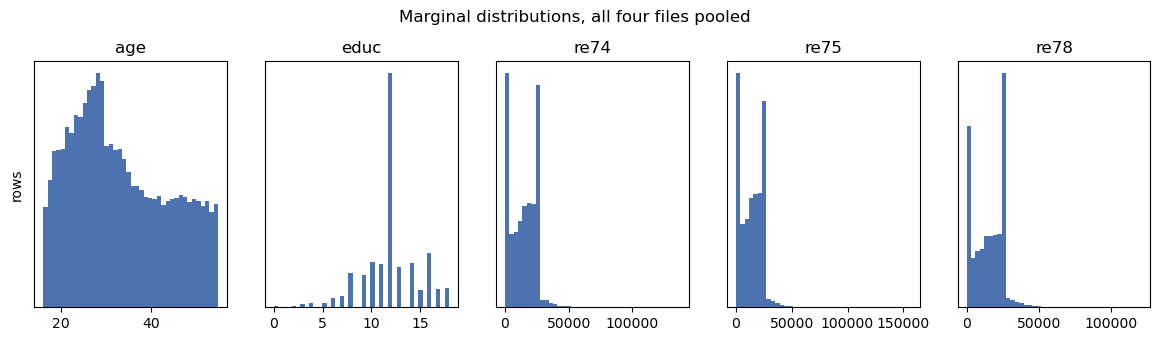

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(figures.FIGSIZE[0] * 1.6, 3.2))
for ax, c in zip(axes, num):
    ax.hist(all_rows[c], bins=40, color="#4c72b0")
    ax.set_title(c)
    ax.set_yticks([])
axes[0].set_ylabel("rows")
fig.suptitle("Marginal distributions, all four files pooled", y=1.04)
figures.save_fig(fig, "numeric_distributions", close=False)
plt.show()

### The earnings variables are topcoded, and only in CPS

The histograms show a spike at the right edge of the earnings distributions. It is not a rounding
artefact: one in four CPS rows carries *exactly* $25,564.67 for `re78`, and that value is also
the CPS maximum. A hard ceiling with mass piled on it is censoring.

**Working hypothesis: the Census Bureau capped these values deliberately before release.** Public
CPS extracts are topcoded for disclosure avoidance, so that a high earner cannot be identified by
their income. The pattern fits: the cap appears only in CPS, it applies to all three earnings
years, and it sits at a single exact value rather than a fuzzy upper region. PSID and the NSW
arms are untouched — PSID reaches \$121,174 and NSW treated \$60,308.

**Why it matters downstream.** `re74` and `re75` are covariates in the propensity model. For
roughly a fifth of CPS candidates we cannot tell someone earning \$26k from someone earning
\$200k, so matching on those variables is really matching on "earnings up to the cap". It also
compresses the CPS earnings variance artificially, which is worth remembering whenever a
standard deviation of CPS earnings is used as a denominator.

This cannot be repaired — censored data cannot be uncensored. It is recorded as a limitation.

share of rows sitting exactly at the candidate cap value

             % at re74 cap  % at re75 cap  % at re78 cap   max re78
nsw_treated           0.00           0.00           0.00  60,307.93
nsw_control           0.00           0.00           0.00  39,483.53
cps                  19.08          18.80          25.92  25,564.67
psid                  0.36           0.12           0.24 121,173.58


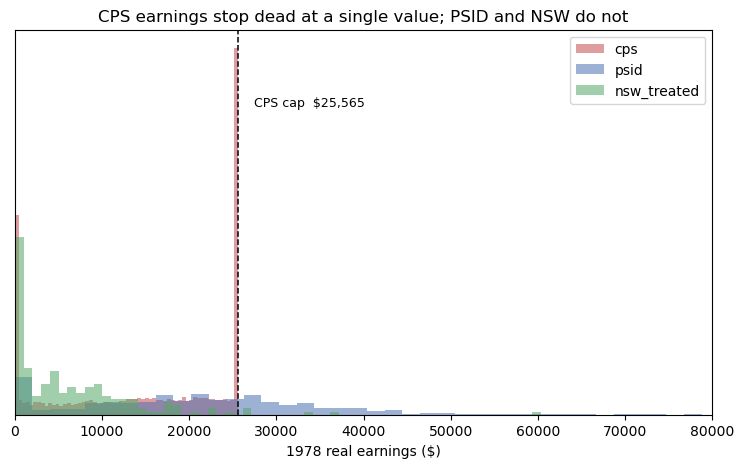

In [9]:
TOPCODE = {"re74": 25862.32, "re75": 25243.55, "re78": 25564.67}

share = pd.DataFrame({
    name: {f"% at {c} cap": (df[c].round(2) == v).mean() * 100 for c, v in TOPCODE.items()}
          | {"max re78": df.re78.max()}
    for name, df in raw.items()
}).T
print("share of rows sitting exactly at the candidate cap value\n")
print(share.round(2).to_string())

fig, ax = figures.new_fig()
for name, colour in [("cps", "#c44e52"), ("psid", "#4c72b0"), ("nsw_treated", "#55a868")]:
    ax.hist(raw[name].re78, bins=60, density=True, alpha=.55, label=name, color=colour)
ax.axvline(TOPCODE["re78"], ls="--", lw=1.1, color="black")
ax.annotate(f"CPS cap  ${TOPCODE['re78']:,.0f}", xy=(TOPCODE["re78"], ax.get_ylim()[1] * .8),
            xytext=(12, 0), textcoords="offset points", fontsize=9)
ax.set_xlim(0, 80_000)
ax.set_xlabel("1978 real earnings ($)")
ax.set_yticks([])
ax.set_title("CPS earnings stop dead at a single value; PSID and NSW do not")
ax.legend()
figures.save_fig(fig, "earnings_topcode", close=False)
plt.show()

## 5. Are the categorical variables coded correctly?

Yes, and the useful finding is that **no further encoding is needed**. Two things to verify.

In [10]:
print("every indicator contains only 0 and 1:")
for c in data.INDICATORS:
    print(f"  {c:10s} unique values {sorted(all_rows[c].unique())}   dtype {all_rows[c].dtype}")

every indicator contains only 0 and 1:
  treat      unique values [0, 1]   dtype int8
  black      unique values [0, 1]   dtype int8
  hisp       unique values [0, 1]   dtype int8
  married    unique values [0, 1]   dtype int8
  nodegree   unique values [0, 1]   dtype int8


### Race: already k-1 dummy coded, with an implicit reference group

`black` and `hisp` never both equal 1, and the two of them plus "neither" account for exactly
100% of every file. That is the signature of a three-level categorical stored as k-1 = 2 dummies,
with the third level as the omitted reference.

**So there is nothing to do.** One-hot encoding these again, or adding a third "other" indicator,
would make the set perfectly collinear because the three would always sum to one. Coefficients on
`black` and `hisp` are already read relative to the reference group.

**What the reference group hides.** It pools everyone who is neither Black nor Hispanic, so white,
Asian, Native American and other respondents are indistinguishable — 85.4% of CPS falls into this
single bucket. Asian participants cannot be identified, and therefore cannot be matched on. If
that status relates to both program entry and later earnings, it is an unmeasured confounder. This
is a limitation of 1970s data collection, not something the analysis can fix, and it belongs in
the write-up.

In [11]:
print("black x hisp, pooled across all files")
print(pd.crosstab(all_rows.black, all_rows.hisp))
print(f"\n  rows with black == 1 and hisp == 1 : {int(((all_rows.black==1)&(all_rows.hisp==1)).sum())}")

race = pd.DataFrame({
    name: {"black %": df.black.mean()*100, "hisp %": df.hisp.mean()*100,
           "neither % (reference)": ((df.black==0)&(df.hisp==0)).mean()*100}
    for name, df in raw.items()
}).T
race["sums to"] = race.sum(axis=1)
print("\nthe three categories account for every row:")
race.round(1)

black x hisp, pooled across all files
hisp       0     1
black             
0      15484  1272
1       2171     0

  rows with black == 1 and hisp == 1 : 0

the three categories account for every row:


,black %,hisp %,neither % (reference),sums to
nsw_treated,84.30,5.90,9.70,100.00
nsw_control,82.70,10.80,6.50,100.00
cps,7.40,7.20,85.40,100.00
psid,25.10,3.30,71.70,100.00


### `nodegree` carries no information that `educ` does not

`nodegree` is exactly `educ < 12`, with zero exceptions across all 18,927 rows. It is a
deterministic recoding, not an independent measurement.

This does not invalidate a propensity score, which only has to balance covariates rather than
yield interpretable coefficients. But it is worth knowing that the `dw` specification includes
`educ`, `educ²` **and** `nodegree`, so three of its columns encode one underlying variable. That
is kept deliberately, because it is the specification Dehejia and Wahba used and the point of
this project is to reproduce their design faithfully, not to improve on it quietly.

In [12]:
print("educ < 12  vs  nodegree == 1")
print(pd.crosstab(all_rows.educ < 12, all_rows.nodegree,
                  rownames=["educ < 12"], colnames=["nodegree"]))
mismatch = int(((all_rows.educ < 12) != (all_rows.nodegree == 1)).sum())
print(f"\n  rows where the two disagree: {mismatch} out of {len(all_rows):,}")

print("\nthe three covariate specifications:")
for s in ["demographics", "with_earnings", "dw"]:
    cols = data.covariate_spec(s)
    print(f"  {s:14s} ({len(cols):>2d}) {cols}")
print(f"\n  outcome re78 present in any specification: "
      f"{any('re78' in data.covariate_spec(s) for s in ['demographics','with_earnings','dw'])}")

educ < 12  vs  nodegree == 1
nodegree       0     1
educ < 12             
False      13088     0
True           0  5839

  rows where the two disagree: 0 out of 18,927

the three covariate specifications:
  demographics   ( 6) ['age', 'educ', 'black', 'hisp', 'married', 'nodegree']
  with_earnings  (10) ['age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75', 'u74', 'u75']
  dw             (16) ['age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75', 'u74', 'u75', 'age2', 'age3', 'educ2', 're74_2', 're75_2', 'educ_re74']

  outcome re78 present in any specification: False


## 6. The experimental benchmark

Now that the data is understood, the answer key.

Admission was decided by lottery, so the two randomized arms are comparable on everything,
measured or not, and a plain difference in mean `re78` is already unbiased. No modelling required.

This also lets us **verify** the pre- versus post-treatment claim from section 2 instead of
assuming it. Under randomization, any variable measured before treatment must come out balanced.
Anything the treatment moved will not.

In [13]:
exp = data.build_experimental()

print("BALANCE TEST INSIDE THE RANDOMIZED EXPERIMENT")
print("(a genuinely pre-treatment variable must show no difference)\n")
rows = []
for v in ["re74", "re75", "re78"]:
    a, b = exp.loc[exp.treat == 1, v], exp.loc[exp.treat == 0, v]
    tt = stats.ttest_ind(a, b, equal_var=False)
    rows.append({"variable": v, "treated": a.mean(), "control": b.mean(),
                 "difference": a.mean() - b.mean(), "p_value": tt.pvalue})
print(pd.DataFrame(rows).set_index("variable").round(3).to_string())
print("\n  re74 and re75 are balanced -> pre-treatment, safe as covariates")
print("  re78 is not             -> this is the outcome")

BALANCE TEST INSIDE THE RANDOMIZED EXPERIMENT
(a genuinely pre-treatment variable must show no difference)

          treated  control  difference  p_value
variable                                       
re74     2,095.57 2,107.03      -11.45     0.98
re75     1,532.06 1,266.91      265.15     0.39
re78     6,349.14 4,554.80    1,794.34     0.01

  re74 and re75 are balanced -> pre-treatment, safe as covariates
  re78 is not             -> this is the outcome


In [14]:
y_t = exp.loc[exp.treat == 1, "re78"]
y_c = exp.loc[exp.treat == 0, "re78"]

bench_est = y_t.mean() - y_c.mean()
test = stats.ttest_ind(y_t, y_c, equal_var=False)      # Welch: unequal variances
ci_lo, ci_hi = test.confidence_interval(0.95)

print(f"treated mean 1978 earnings : ${y_t.mean():>9,.0f}  (n={len(y_t)})")
print(f"control mean 1978 earnings : ${y_c.mean():>9,.0f}  (n={len(y_c)})")
print(f"\nBENCHMARK ATT              : ${bench_est:>9,.0f}")
print(f"95% CI                     : [${ci_lo:,.0f}, ${ci_hi:,.0f}]   width ${ci_hi-ci_lo:,.0f}")
print(f"p-value                    : {test.pvalue:.4f}")

treated mean 1978 earnings : $    6,349  (n=185)
control mean 1978 earnings : $    4,555  (n=260)

BENCHMARK ATT              : $    1,794
95% CI                     : [$474, $3,115]   width $2,641
p-value                    : 0.0079


### What randomization bought

The two randomized arms are near-identical on their covariates: under a year apart in age, a
quarter of a year in education, a point in race. Nobody adjusted anything to produce that.

Hold this table in mind. In the next section the control group is replaced, and the same
comparison falls apart.

In [15]:
covs = data.covariate_spec("with_earnings")
arms = exp.groupby("treat")[covs].mean().T
arms.columns = ["NSW control (n=260)", "NSW treated (n=185)"]
arms["difference"] = arms.iloc[:, 1] - arms.iloc[:, 0]
arms

,NSW control (n=260),NSW treated (n=185),difference
age,25.05,25.82,0.76
educ,10.09,10.35,0.26
black,0.83,0.84,0.02
hisp,0.11,0.06,-0.05
married,0.15,0.19,0.04
nodegree,0.83,0.71,-0.13
re74,"2,107.03","2,095.57",-11.45
re75,"1,266.91","1,532.06",265.15
u74,0.75,0.71,-0.04
u75,0.68,0.60,-0.08


## 7. Build the two observational samples

The research design of LaLonde (1986): discard the 260 randomized controls, pretend we only ever
had the 185 participants, and take a comparison group from a national survey instead.

Two survey pools are used and they are kept **strictly separate**. They are two independent
replications of the same test at different difficulty levels, and merging them would let the
matching step draw from whichever pool is easier, hiding the very problem worth exposing.

In [16]:
samples = {pool: data.build_observational(pool) for pool in ["cps", "psid"]}

rows = []
for pool, df in samples.items():
    t, c = df.loc[df.treat == 1, "re78"], df.loc[df.treat == 0, "re78"]
    rows.append({"pool": pool.upper(),
                 "n_treated": int((df.treat == 1).sum()),
                 "n_control": int((df.treat == 0).sum()),
                 "treated_share": (df.treat == 1).mean(),
                 "mean_re78_treated": t.mean(),
                 "mean_re78_control": c.mean(),
                 "naive_difference": t.mean() - c.mean()})
pd.DataFrame(rows).set_index("pool")

,n_treated,n_control,treated_share,mean_re78_treated,mean_re78_control,naive_difference
pool,,,,,,
CPS,185,15992,0.01,"6,349.14","14,846.66","-8,497.52"
PSID,185,2490,0.07,"6,349.14","21,553.92","-15,204.78"


The naive comparison is not merely biased. It has the **wrong sign** and is off by more than ten
thousand dollars. Read literally, it says job training destroyed participants' earnings.

It also shows the pools are not interchangeable: PSID respondents earn more, so the same treated
group looks even worse against them. And treated units are a small minority of each sample, about
1% under CPS and 7% under PSID, which is what will push the propensity scores in notebook 02
towards zero.

Measuring *how* far apart the groups are belongs with the propensity model, since that is the
imbalance the model exists to correct, so it moves to notebook 02 where the before-and-after
comparison can sit side by side.

## 8. Save

Each notebook hands its work to the next through files rather than memory, so any stage can be
re-run alone and a reader can inspect the intermediate products on GitHub without executing
anything. The benchmark goes out as JSON so notebook 04 can score its estimates without reloading
the experimental arms.

In [17]:
for pool, df in samples.items():
    path = data.save_stage(df, f"01_sample_{pool}")
    print(f"{path.name:24s} {df.shape[0]:>6,} rows x {df.shape[1]} cols")

bench = {
    "estimand": "ATT",
    "outcome": "re78",
    "estimate": float(bench_est),
    "ci_lo": float(ci_lo),
    "ci_hi": float(ci_hi),
    "p_value": float(test.pvalue),
    "n_treated": int(len(y_t)),
    "n_control": int(len(y_c)),
    "source": "NSW randomized experiment (Dehejia-Wahba re74 subsample)",
}
bench_path = data.OUT_DIR / "01_benchmark.json"
bench_path.write_text(json.dumps(bench, indent=2))
print(f"\n{bench_path.name}: ${bench['estimate']:,.0f}  [{bench['ci_lo']:,.0f}, {bench['ci_hi']:,.0f}]")

01_sample_cps.csv        16,177 rows x 20 cols
01_sample_psid.csv        2,675 rows x 20 cols

01_benchmark.json: $1,794  [474, 3,115]
